# AAPL Price Direction â€” Model Training & Evaluation
XGBoost vs Logistic Regression using sentiment + technical features.

## 1. Setup

In [34]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import os

from src.features.engineering import load_and_merge, temporal_split, get_feature_matrix
from src.evaluation.metrics import (
    evaluate_classifier, plot_roc_curve,
    plot_confusion_matrix, plot_feature_importance, backtest_simulation
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load & Prepare Data

In [37]:
df = load_and_merge('../data/raw/final_dataset.csv')

train_df, test_df = temporal_split(df, split_date='2024-09-01')

X_train, y_train, FEATURES = get_feature_matrix(train_df)
X_test,  y_test,  _        = get_feature_matrix(test_df)

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")

Train: 2023-01-25 → 2024-08-30 (403 rows)
Test:  2024-09-03 → 2024-12-30 (83 rows)
Train UP%: 55.1%  |  Test UP%: 59.0%
Features (10): ['avg_sentiment', 'rolling_3d_sentiment', 'rolling_7d_sentiment', 'daily_return', 'price_momentum_5d', 'high_low_range', 'ma_5', 'ma_10', 'volume', 'day_of_week']
X_train shape: (403, 10)  |  X_test shape: (83, 10)


## 3. Logistic Regression

In [38]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)

lr_results = evaluate_classifier(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_test, y_test
)


  Logistic Regression
Train Accuracy : 0.5459
Test  Accuracy : 0.5783
Gap (overfit)  : -0.0324  ✓ ok
ROC-AUC        : 0.5102
Avg Precision  : 0.6048

Confusion Matrix:
[[ 1 33]
 [ 2 47]]

Classification Report:
              precision    recall  f1-score   support

           0      0.333     0.029     0.054        34
           1      0.588     0.959     0.729        49

    accuracy                          0.578        83
   macro avg      0.460     0.494     0.391        83
weighted avg      0.483     0.578     0.452        83



In [39]:
# LR coefficients (inline â€” feature_importance uses .feature_importances_ so is XGBoost only)
lr_coefs = pd.Series(
    lr_pipe.named_steps['lr'].coef_[0],
    index=FEATURES
).sort_values(key=abs, ascending=False)

print("\nLogistic Regression Coefficients (sorted by |coef|):")
print(lr_coefs.to_string())


Logistic Regression Coefficients (sorted by |coef|):
daily_return            0.145471
price_momentum_5d      -0.095017
rolling_3d_sentiment    0.072277
high_low_range          0.053217
day_of_week             0.032803
ma_10                   0.029865
ma_5                   -0.029267
volume                 -0.024741
avg_sentiment           0.001989
rolling_7d_sentiment   -0.000950


## 4. XGBoost

In [40]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"Best iteration: {xgb.best_iteration}")

xgb_results = evaluate_classifier(
    'XGBoost', xgb,
    X_train, y_train, X_test, y_test
)

Best iteration: 13

  XGBoost
Train Accuracy : 0.6849
Test  Accuracy : 0.5663
Gap (overfit)  : 0.1186  ⚠ possible overfit
ROC-AUC        : 0.5756
Avg Precision  : 0.6752

Confusion Matrix:
[[ 7 27]
 [ 9 40]]

Classification Report:
              precision    recall  f1-score   support

           0      0.438     0.206     0.280        34
           1      0.597     0.816     0.690        49

    accuracy                          0.566        83
   macro avg      0.517     0.511     0.485        83
weighted avg      0.532     0.566     0.522        83



## 4b. Naive Baseline

In [41]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

dummy_results = evaluate_classifier(
    'Naive Baseline (always predict majority class)', dummy,
    X_train, y_train, X_test, y_test
)


  Naive Baseline (always predict majority class)
Train Accuracy : 0.5509
Test  Accuracy : 0.5904
Gap (overfit)  : -0.0395  ✓ ok
ROC-AUC        : 0.5000
Avg Precision  : 0.5904

Confusion Matrix:
[[ 0 34]
 [ 0 49]]

Classification Report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        34
           1      0.590     1.000     0.742        49

    accuracy                          0.590        83
   macro avg      0.295     0.500     0.371        83
weighted avg      0.349     0.590     0.438        83



C:\Users\split\anaconda3\envs\sentiment-project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\split\anaconda3\envs\sentiment-project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\split\anaconda3\envs\sentiment-project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

## 5. Model Comparison â€” ROC Curves

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/figures/roc_curves.png'

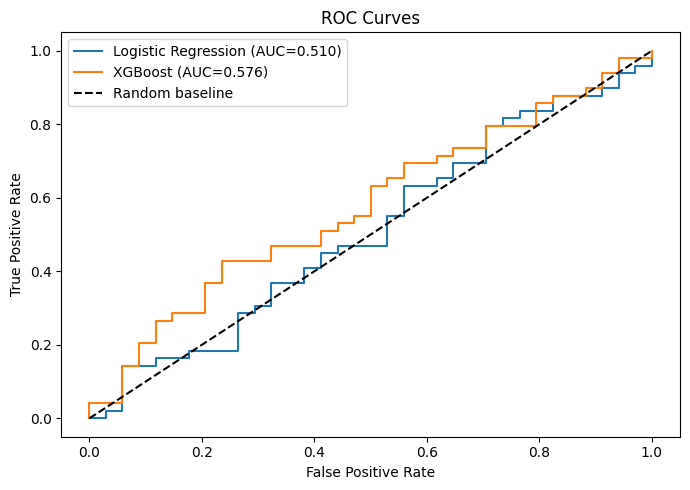

In [42]:
models_dict = {
    'Logistic Regression': lr_pipe,
    'XGBoost': xgb,
}
plot_roc_curve(models_dict, X_test, y_test)

# Summary table (dummy included separately — no predict_proba for ROC)
summary = pd.DataFrame([dummy_results, lr_results, xgb_results]).set_index('model')
print("Model Comparison Summary:")
print(summary[['train_acc', 'test_acc', 'gap', 'roc_auc', 'avg_precision']].to_string())

## 6. XGBoost Feature Importance

C:\Users\split\OneDrive\Desktop\sentiment analysis project\CAP_3764_2026_Spring_Team_3\notebooks\..\src\evaluation\metrics.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance[idx], y=np.array(feature_names)[idx], palette='Blues_r')


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/figures/feature_importance.png'

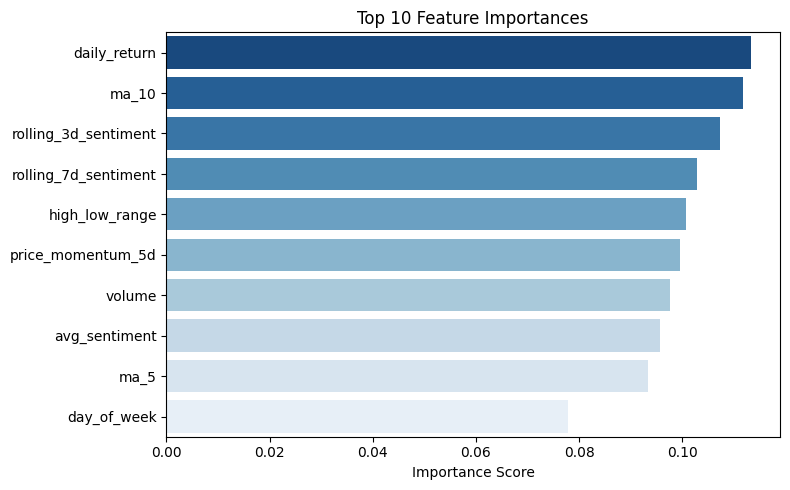

In [32]:
plot_feature_importance(xgb, FEATURES, top_n=10)

## 7. Backtest Simulation
Long-only strategy: buy AAPL on days the best model predicts UP.

Best model by ROC-AUC: XGBoost

  Backtest Results (Test Period)
Strategy return  : 24.4%
Buy-hold return  : 10.3%
Days traded      : 67 / 83


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/figures/backtest.png'

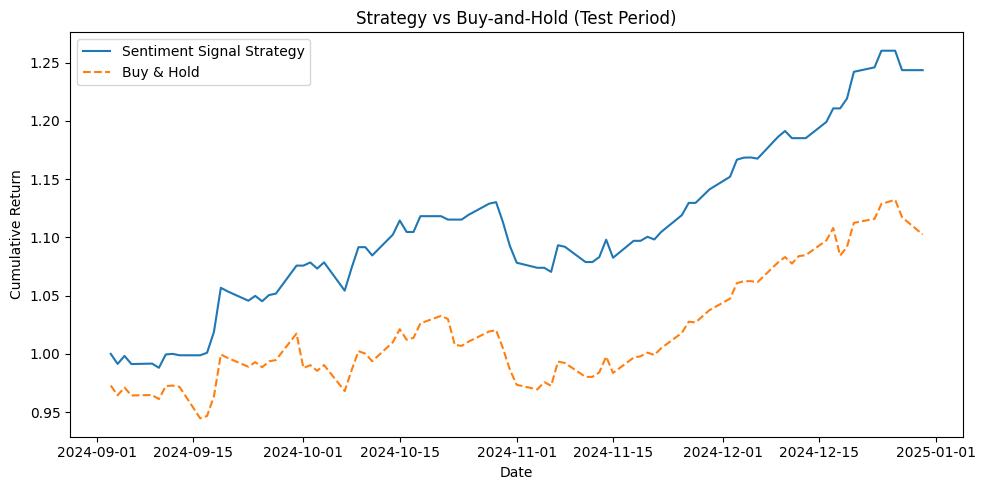

In [43]:
# Use whichever model has higher ROC-AUC
best_model_name = max([lr_results, xgb_results], key=lambda r: r['roc_auc'])['model']
best_model = models_dict[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")

backtest_results = backtest_simulation(
    best_model, X_test, y_test,
    test_df.reset_index(drop=True)
)